# **Análisis-Algoritmos y Visualización del Grafo de la Red ‘X’**

## Objetivo

El objetivo principal de este proyecto es analizar y visualizar la estructura de un **gran grafo de red social** para descubrir patrones interesantes y obtener información sobre la **conectividad social**, las **estructuras de la comunidad** y las **propiedades de la red**. En particular, se busca entender cómo se conectan los usuarios entre sí, la distribución de sus ubicaciones geográficas y las características globales del grafo.

---
## Nombre del proyecto: **Red Social ‘X’**

### Fuente:
- [Conjunto de datos](https://drive.google.com/drive/folders/1XvzgZ3NKo3EruGOHDirM6bQwfc8fejpl?usp=sharing)

### Descripción:
Este conjunto de datos es un subconjunto de los **10 millones de usuarios** de la red social ‘X’, junto con sus conexiones y ubicaciones. El grafo creado considera a los **usuarios como nodos** y sus **conexiones como aristas**. Estas conexiones forman un **componente conectado** dentro del grafo total. Es importante señalar que la relación **"seguidor-seguido"** no es mutua: **"X sigue a Y"** no implica **"Y sigue a X"**.


### Archivos:
1. **Ubicación**: `"10_million_location.txt.zip"`  
   Contiene las latitudes y longitudes de cada usuario en el formato:
   lat_1, long_1
   lat_2, long_2
   lat_3, long_3

Donde **lat_1, long_1** son las coordenadas geográficas del primer usuario, y así sucesivamente.

3. **Usuario**: `"10_million_user.txt.zip"`  
Contiene la lista de adyacencia para cada usuario. La i-ésima fila representa la lista de adyacencia del i-ésimo usuario, con los seguidores del usuario i. El formato es:
   2, 3, 4, 5, 6, ...
   1, 27188, 50986, ...
   1, 34590, 13474, ...
   
Cada número es un usuario al que sigue el usuario correspondiente.

---

## Descripción del Código

### 1. **Importación de bibliotecas y configuración inicial**

El código comienza importando las bibliotecas necesarias para la manipulación de datos y la visualización de los resultados. Estas bibliotecas incluyen:

- **`numpy`**: para la manipulación eficiente de matrices y operaciones matemáticas.
- **`matplotlib.pyplot`**: para la visualización gráfica de datos.
- **`networkx`**: para trabajar con estructuras de grafos.
- **`logging`**: para registrar información y errores durante la ejecución.
- **`pandas`**: para organizar y presentar estadísticas de manera estructurada.
- **`os`**: para gestionar archivos del sistema, como verificar la existencia de archivos.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import logging
from collections import defaultdict
import os

import pandas as pd
import time

# Configurar logging
logging.basicConfig(level=logging.INFO)


### 2. **Validación y carga de archivos de entrada**

Este bloque asegura que los archivos de datos necesarios existan y estén correctamente formateados:

- **`validar_archivo(path)`**: verifica que el archivo exista en la ruta proporcionada.

In [8]:
# Validar existencia del archivo
def validar_archivo(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Archivo no encontrado: {path}")

- **`cargar_ubicaciones(path)`**: carga las coordenadas geográficas de los usuarios desde el archivo de ubicación.

In [9]:

# Cargar ubicaciones (lat, long)
def cargar_ubicaciones(path):
    validar_archivo(path)
    logging.info("Cargando ubicaciones...")
    return np.loadtxt(path, delimiter=',')

- **`cargar_grafo(path)`**: carga la lista de adyacencia de los usuarios, representando las conexiones entre nodos del grafo.

In [1]:
# Cargar grafo (lista de adyacencia) en streaming
def cargar_grafo(path):
    validar_archivo(path)
    logging.info("Cargando conexiones del grafo...")
    grafo = defaultdict(list)
    with open(path, 'r') as f:
        for i, linea in enumerate(f, 1):
            try:
                conexiones = list(map(int, linea.strip().split(',')))
                grafo[i] = conexiones
            except ValueError as e:
                logging.warning(f"Error de formato en línea {i}: {e}")
    return grafo

In [11]:
# Cargar ubicaciones
start = time.time()
ubicaciones = cargar_ubicaciones("10_million_location.txt")
end = time.time()
print(f"Ubicaciones cargadas: {ubicaciones.shape} en {end - start:.2f} segundos")

# Cargar grafo
start = time.time()
grafo = cargar_grafo("10_million_user.txt")
end = time.time()
print(f"Usuarios cargados: {len(grafo)} en {end - start:.2f} segundos")

INFO:root:Cargando ubicaciones...
INFO:root:Cargando conexiones del grafo...


Ubicaciones cargadas: (10000000, 2) en 10.58 segundos
Usuarios cargados: 10000000 en 418.57 segundos



### 3. **Cálculo de estadísticas del grafo**

Este bloque calcula algunas métricas clave del grafo:

- **Número de nodos y aristas**.
- **Grado promedio, mínimo y máximo** de los nodos del grafo.

Estas métricas proporcionan una visión general sobre la estructura del grafo, lo que puede ser útil para identificar patrones de conectividad.

In [12]:
# Calcular estadísticas
n_nodos = len(grafo)
n_aristas = sum(len(v) for v in grafo.values())
grado_promedio = n_aristas / n_nodos
grados = [len(v) for v in grafo.values()]
grado_max = max(grados)
grado_min = min(grados)

# Crear tabla con pandas
df_stats = pd.DataFrame({
    "Métrica": [
        "Número de nodos",
        "Número de aristas",
        "Grado promedio",
        "Grado mínimo",
        "Grado máximo"
    ],
    "Valor": [
        f"{n_nodos:,}",
        f"{n_aristas:,}",
        f"{grado_promedio:.2f}",
        f"{grado_min}",
        f"{grado_max}"
    ]
})

# Mostrar tabla
df_stats.style.set_table_attributes("style='display:inline'").set_caption("Estadísticas Básicas del Grafo")


,Métrica,Valor
0,Número de nodos,"10,000,000"
1,Número de aristas,"169,488,182"
2,Grado promedio,16.95
3,Grado mínimo,1
4,Grado máximo,18187


### 4. **Visualización de un subgrafo**

En este bloque se visualiza una **parte del grafo** para entender mejor la conectividad entre los usuarios. El subgrafo se selecciona de los primeros nodos y se dibuja utilizando el layout de resorte (`spring layout`), el cual organiza los nodos de manera intuitiva según sus relaciones de conectividad.


C:\Users\Acer\AppData\Local\Temp\ipykernel_2864\613752423.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


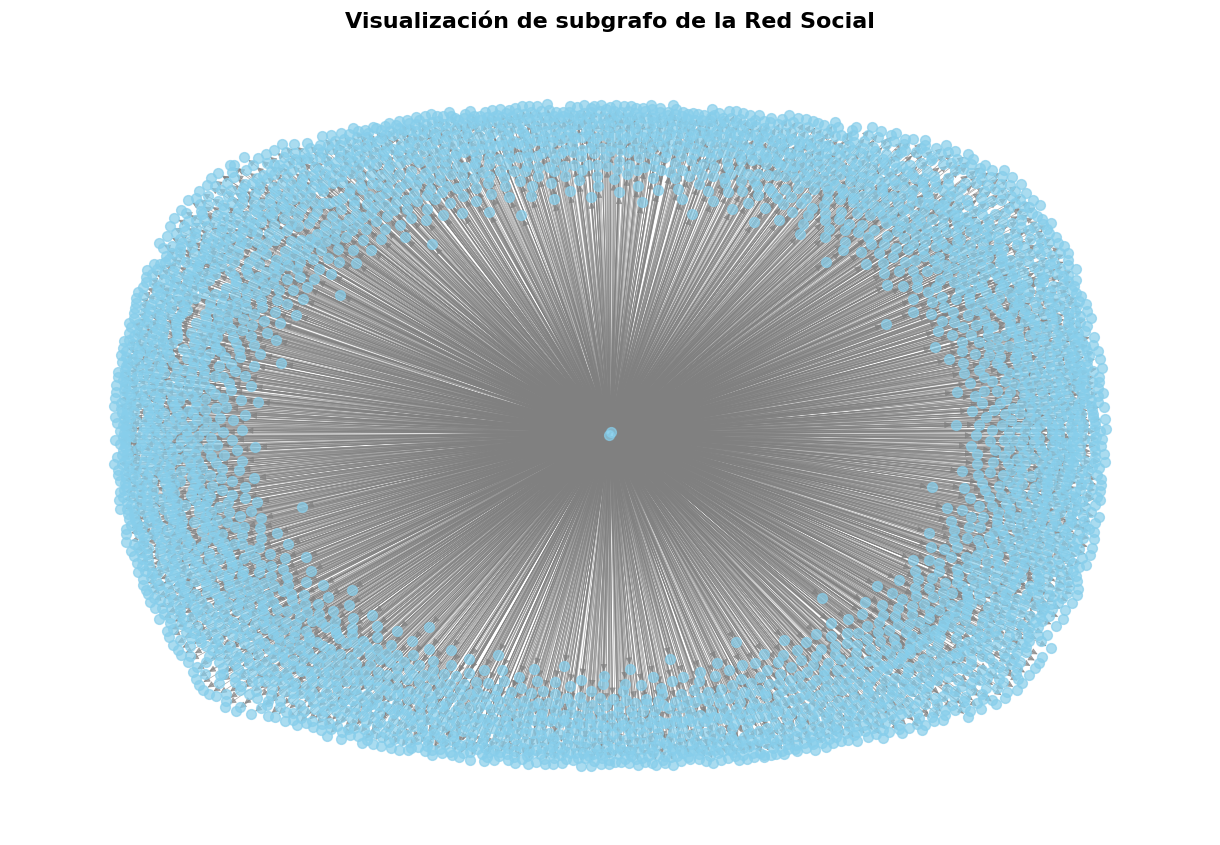

In [13]:
# Tomar los primeros "1000" nodos para visualización
subgrafo_dict = dict(list(grafo.items())[:2])

G = nx.DiGraph()
for nodo, vecinos in subgrafo_dict.items():
    for vecino in vecinos:
        G.add_edge(nodo, vecino)

# Generar la figura
plt.figure(figsize=(12, 8))

# Usar el layout 'spring' ajustado para una mejor distribución
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Dibujar el grafo con mejoras visuales
nx.draw(
    G, pos, 
    node_size=50,                 # Tamaño de los nodos
    node_color='skyblue',          # Color de los nodos
    edge_color='gray',             # Color de las aristas
    width=0.5,                    # Grosor de las aristas
    alpha=0.7,                    # Transparencia de los nodos y aristas
    with_labels=False,             # Desactivar etiquetas de nodos
    font_size=8,                   # Tamaño de la fuente de las etiquetas
    font_color='black',            # Color de las etiquetas
    font_weight='bold'             # Peso de la fuente
)

# Mejorar la visualización del título
plt.title("Visualización de subgrafo de la Red Social", fontsize=16, fontweight='bold')

# Ajustar la visualización para no cortar el grafo
plt.tight_layout()

# Mostrar el gráfico
plt.show()



### 5. **Visualización geográfica de usuarios**

Este bloque genera un gráfico de dispersión que muestra la **distribución geográfica de los usuarios** a partir de sus coordenadas de latitud y longitud. El gráfico proporciona una visión clara de cómo los usuarios están distribuidos a nivel global y permite identificar posibles concentraciones geográficas.


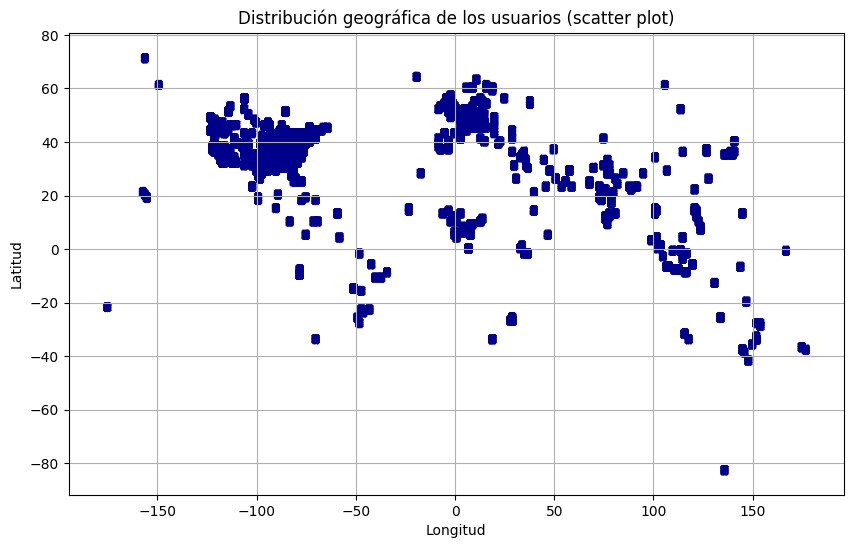

In [14]:
# Extraer latitudes y longitudes
latitudes = ubicaciones[:, 0]
longitudes = ubicaciones[:, 1]

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(longitudes, latitudes, s=0.01, alpha=0.3, color='darkblue')  # s controla el tamaño del punto
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución geográfica de los usuarios (scatter plot)')
plt.grid(True)
plt.show()



---

## Resultados Esperados

Al completar este análisis, se espera obtener una comprensión más profunda sobre la **estructura de la red social** de la red ‘X’. Esto incluye:

- Identificar **grupos de usuarios** altamente conectados.
- Analizar la **distribución geográfica** de los usuarios para comprender mejor sus patrones de interacción.
- Evaluar la **conectividad global** del grafo, incluyendo sus propiedades de densidad y centralidad.

---

## Conclusiones

A través de este análisis y visualización del grafo de la red social ‘X’, podemos obtener información valiosa sobre la conectividad de los usuarios, la estructura de la comunidad y las propiedades globales de la red. Este tipo de análisis puede ser útil para estudiar fenómenos como la propagación de información, la influencia de usuarios clave y el comportamiento colectivo dentro de redes sociales de gran escala.

